# PVT Corners and Monte Carlo Analysis — Dynamic Comparator
---
**PDK:** GF180MCU 3.3 V  \
**Tools:** ngspice + Python (Jupyter)

Sweeps **45 PVT corners** (5 process × 3 voltage × 3 temperature) and runs
**Monte Carlo** simulations with the GF180MCU mismatch models enabled.

In [1]:
#Function to skip cells using boolean variables

from IPython.core.magic import register_cell_magic

@register_cell_magic
def run_if(line, cell):
    """
    Custom magic command to conditionally execute an entire cell.
    It evaluates the boolean condition written next to %%run_if
    """
    # Evaluate the boolean condition provided in the line
    if eval(line):
        # If True, execute the entire cell's code
        get_ipython().run_cell(cell)
    else:
        # If False, skip the cell and print a bypass message
        print(f"⏭️ Cell skipped. The condition ({line}) evaluated to False.")

In [2]:
import os
import subprocess
import re
import numpy as np

# ── Simulation control ────────────────────────────────────────────────────────
RUN_PVT = True 
RUN_MC =  True
RUN_PVT_MC = RUN_PVT and RUN_MC
MC_SAMPLES   = 200     # Number of Monte Carlo seeds


SCH_NAME = 'tb_strongARM_offset'   # Base name of the netlist/raw file

PDK_PATH = '/foss/pdks/gf180mcuD'
SIM_DIR  = '/headless/.xschem/simulations' # Netlist lives here
RAW_DIR  = '/headless/.xschem/simulations'   # Raw files written here

os.makedirs(RAW_DIR, exist_ok=True)


# ── Design specifications ─────────────────────────────────────────────────────
SPEC_MAX_DELAY  = 3.0e-9    # Maximum propagation delay [s]
SPEC_MAX_POWER  = 250e-6    # Maximum average power     [W]
SPEC_MAX_OFFSET = 15e-3   # Maximum dynamic offset    [V]



print(f"SCH_NAME : {SCH_NAME}")
print(f"SIM_DIR  : {SIM_DIR}")
print(f"Specs    : Delay < {SPEC_MAX_DELAY*1e9:.1f} ns | Power < {SPEC_MAX_POWER*1e6:.1f} uW | Offset < {SPEC_MAX_OFFSET*1e3:.1f} mV")


SCH_NAME : tb_strongARM_offset
SIM_DIR  : /headless/.xschem/simulations
Specs    : Delay < 3.0 ns | Power < 250.0 uW | Offset < 15.0 mV


In [3]:
class NgspiceRawReader:
    # Minimal ASCII raw-file reader for ngspice transient simulations.
    # When '.control / set filetype=ascii / .endc' is used in the netlist,
    # ngspice writes waveform data in a plain-text 'raw' format. This class
    # parses that file and exposes each signal as a NumPy array.

    def __init__(self, filepath):
        self.filepath  = filepath
        self.variables = []
        self.data      = {}
        self.load()

    def load(self):
        if not os.path.exists(self.filepath):
            raise FileNotFoundError(f"Raw file not found: {self.filepath}")
        with open(self.filepath, 'r') as f:
            lines = f.readlines()

        data_start = 0
        j = 0
        for idx, line in enumerate(lines):
            if line.startswith('Variables:'):
                j = idx + 1
                while not lines[j].startswith('Values:'):
                    parts = lines[j].strip().split()
                    if len(parts) >= 3:
                        self.variables.append(parts[1])
                    j += 1
            if line.startswith('Values:'):
                data_start = j + 1
                break

        for var in self.variables:
            self.data[var] = []

        i = data_start
        while i < len(lines):
            line = lines[i].strip()
            if not line:
                i += 1
                continue
            parts = line.split()
            if len(parts) == 2:
                self.data[self.variables[0]].append(float(parts[1]))
                for v_idx in range(1, len(self.variables)):
                    self.data[self.variables[v_idx]].append(float(lines[i + v_idx].strip()))
                i += len(self.variables)
            else:
                i += 1

        for var in self.variables:
            self.data[var] = np.array(self.data[var])

    def get_signal(self, name):
        # Return the NumPy array for a signal by name (case-insensitive).
        for var in self.variables:
            if var.lower() == name.lower():
                return self.data[var]
        raise KeyError(f"Signal '{name}' not found. Available: {self.variables}")

## PVT Corner Sweep — 45 Combinations (5 process × 3 VDD × 3 Temp)

In [4]:
%%run_if RUN_PVT
import itertools
import pandas as pd
import numpy as np
import subprocess
import re
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import display


mos_corners  = ['typical', 'ff', 'ss', 'fs', 'sf']#
voltages     = [3.0, 3.3, 3.6]#
temperatures = [-40, 27, 125]#

pvt_corners = [
    {'mos': m, 'vdd': v, 'temp': t}
    for m, v, t in itertools.product(mos_corners, voltages, temperatures)
]

print(f"Starting PVT sweep — {len(pvt_corners)} corners, 4 threads ...\n")

# Read the base netlist using SCH_NAME (set in Cell 1)
with open(os.path.join(SIM_DIR, f'{SCH_NAME}.spice'), 'r') as f:
    orig_spice = f.read()

def run_pvt(args):
    idx, c = args
    mos, vdd, temp = c['mos'], c['vdd'], c['temp']
    spice = orig_spice

    # 1. Swap process corner library (sigue siendo texto de modelo -> replace)
    spice = spice.replace(
        ".lib '/foss/pdks/gf180mcuD/libs.tech/ngspice/sm141064.ngspice' typical",
        f".lib '/foss/pdks/gf180mcuD/libs.tech/ngspice/sm141064.ngspice' {mos}"
    )



    raw_path = f"/tmp/pvt_wf_{idx+1}.raw"
    spice += (
        "\n.control\n"
        "  set filetype=ascii\n"
        f"  alterparam VDD = {vdd}\n"
        "  reset\n"
        f"  option temp={temp}\n"
        "  run\n"
        f"  write {raw_path}\n"
        "  quit\n"
        ".endc\n"
    )

    tb = f"/tmp/tb_pvt_{idx+1}.spice"
    with open(tb, 'w') as f:
        f.write(spice)
    res = subprocess.run(
        ['/foss/tools/ngspice/bin/ngspice', '-b', tb],
        capture_output=True, text=True
    )
    try:
        os.remove(tb)
    except Exception:
        pass

    def parse(pattern):
        m = re.search(pattern + r'\s*=\s*([0-9e.+\-]+)', res.stdout, re.IGNORECASE)
        return float(m.group(1)) if m else np.nan

    tpd   = parse(r'tpd_on')
    vos   = parse(r'ofset')
    p_avg = parse(r'p_avg')

    # Read waveforms from the raw file
    waveform = None
    try:
        reader = NgspiceRawReader(raw_path)
        waveform = {
            'mos':  mos, 'vdd': vdd, 'temp': temp,
            'time': reader.get_signal('time') * 1e9,  # Convert s -> ns
            'v_on': reader.get_signal('v(on)'),
            'v_op': reader.get_signal('v(op)'),
        }
    except Exception:
        pass
    finally:
        try:
            os.remove(raw_path)
        except Exception:
            pass

    return {
        '_idx':     idx,
        '_wf':      waveform,
        'Process':  mos,
        'VDD (V)':  vdd,
        'Temp (C)': temp,
        'tpd (ps)': tpd   * 1e12 if not np.isnan(tpd)   else np.nan,
        'Pavg (uW)':p_avg * 1e6  if not np.isnan(p_avg) else np.nan,
        'Vos (mV)': vos   * 1e3  if not np.isnan(vos)   else np.nan,
    }

# ── Run all 45 corners in parallel (4 threads) ─────────────────────────────
# Run this inside the Docker container to check how many CPU threads
# are available for parallel simulation (max_workers should not exceed this):
#   nproc --all
results_raw = [None] * len(pvt_corners)
done = 0
with ThreadPoolExecutor(max_workers=4) as ex: #Replace 4 with the number of threads you have available.
    futs = {ex.submit(run_pvt, (i, c)): i for i, c in enumerate(pvt_corners)}
    for fut in as_completed(futs):
        r = fut.result()
        results_raw[r['_idx']] = r
        done += 1
        if done % 5 == 0 or done == len(pvt_corners):
            print(f"  -> {done}/{len(pvt_corners)} corners done.")

# Separate waveforms from scalar results
pvt_waveforms = [r.pop('_wf') for r in results_raw]
pvt_waveforms = [w for w in pvt_waveforms if w is not None]
for r in results_raw:
    r.pop('_idx', None)

df_pvt = pd.DataFrame(results_raw)
print(f"\nPVT complete — {len(df_pvt)} rows | Waveforms collected: {len(pvt_waveforms)}\n")
display(df_pvt)



Starting PVT sweep — 45 corners, 4 threads ...

  -> 5/45 corners done.
  -> 10/45 corners done.
  -> 15/45 corners done.
  -> 20/45 corners done.
  -> 25/45 corners done.
  -> 30/45 corners done.
  -> 35/45 corners done.
  -> 40/45 corners done.
  -> 45/45 corners done.

PVT complete — 45 rows | Waveforms collected: 45



,Process,VDD (V),Temp (C),tpd (ps),Pavg (uW),Vos (mV)
0,typical,3.0,-40,2043.5420,109.2770,2.08037
1,typical,3.0,27,2178.0460,114.0790,2.11380
2,typical,3.0,125,2303.4610,121.8670,-19.79860
3,typical,3.3,-40,1268.0180,141.0500,1.87087
4,typical,3.3,27,1430.2840,147.4220,1.91379
5,typical,3.3,125,1617.9590,157.3120,-19.82070
6,typical,3.6,-40,958.0654,180.6560,1.78904
7,typical,3.6,27,1099.6540,187.6260,1.82694
8,typical,3.6,125,1279.6060,198.7610,-19.83760
9,ff,3.0,-40,1409.8570,120.1040,1.90998


## PVT Waveform Overlay — v(On) and v(Op), All 45 Corners

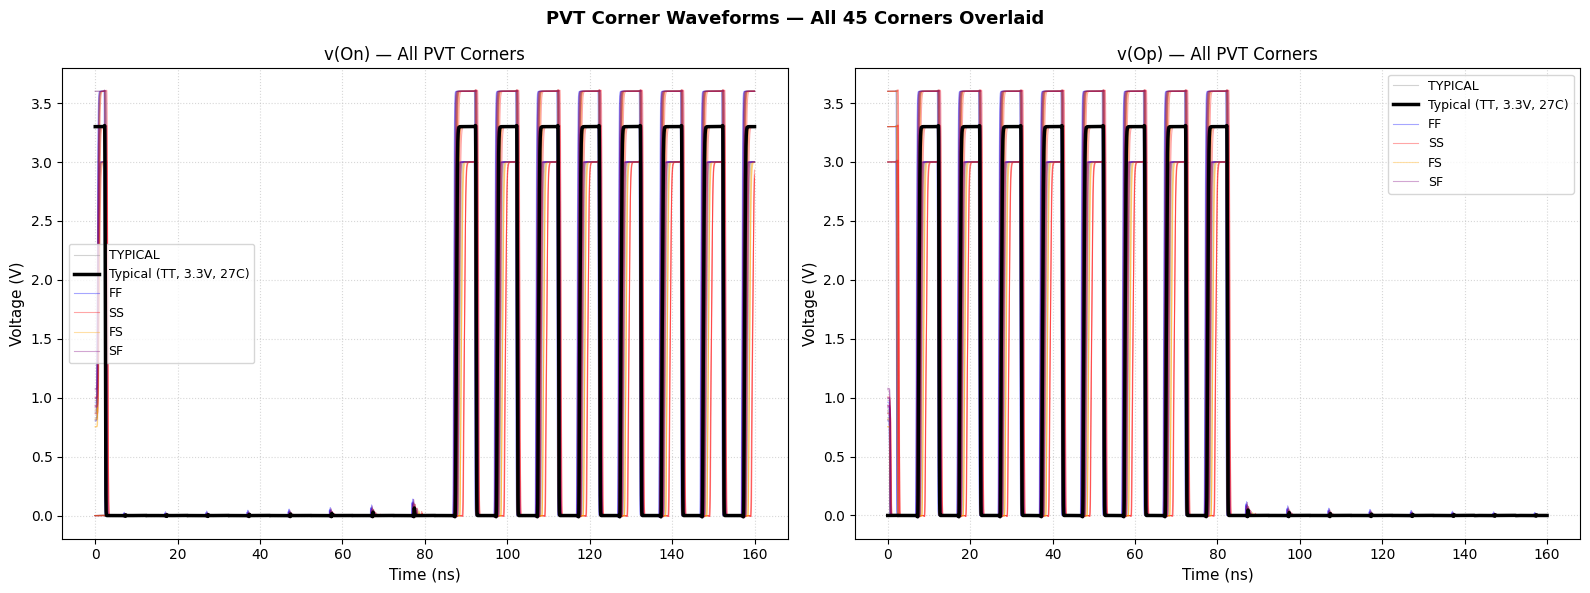

Saved: /foss/designs/Chipathon-2026-OnChipSAR/designs/sar_adc/comparator/Testbench/pvt_waveforms_overlay.png
=== PVT CORNER SUMMARY REPORT (BEST / TYPICAL / WORST PER SPEC) ===


Case,MOS,VDD (V),Temp (°C),Delay (ps),Power (uW),Offset (mV)
"Typical (TT, 3.3V, 27°C)",TYPICAL,3.30,27.0,1430.28,147.42,1.91
Best Case — Delay (ps),FF,3.60,-40.0,778.72,197.29,1.74
Worst Case — Delay (ps),SS,3.00,27.0,3276.51,95.86,2.41
Best Case — Power (uW),SS,3.00,-40.0,3253.45,90.89,2.41
Worst Case — Power (uW),FF,3.60,125.0,1052.77,218.15,-19.86
Best Case — Offset (mV),FF,3.60,-40.0,778.72,197.29,1.74
Worst Case — Offset (mV),FF,3.60,27.0,897.40,205.15,-19.89


In [11]:
%%run_if RUN_PVT
import matplotlib.pyplot as plt

if not pvt_waveforms:
    print("No waveform data. Run the PVT simulation cell first.")
else:
    # One color per process corner, consistent across both plots
    proc_colors = {'typical': 'gray', 'ff': 'blue', 'ss': 'red',
                   'fs': 'orange', 'sf': 'purple'}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('PVT Corner Waveforms — All 45 Corners Overlaid',
                 fontsize=13, fontweight='bold')

    legend_seen = set()

    for wf in pvt_waveforms:
        is_typical = (wf['mos'] == 'typical' and
                      wf['vdd'] == 3.3 and
                      wf['temp'] == 27)

        if is_typical:
            # Typical corner: thick black line on top (highest z-order)
            clr, lw, alpha, zorder = 'black', 2.5, 1.0, 10
            label = 'Typical (TT, 3.3V, 27C)'
        else:
            # Other corners: thin semi-transparent lines colored by process
            clr    = proc_colors.get(wf['mos'], 'gray')
            lw, alpha, zorder = 0.8, 0.35, 2
            # Add legend entry once per process corner
            label  = wf['mos'].upper() if wf['mos'] not in legend_seen else None
            if wf['mos'] not in legend_seen:
                legend_seen.add(wf['mos'])

        ax1.plot(wf['time'], wf['v_on'], color=clr, linewidth=lw,
                 alpha=alpha, zorder=zorder, label=label)
        ax2.plot(wf['time'], wf['v_op'], color=clr, linewidth=lw,
                 alpha=alpha, zorder=zorder, label=label)

    for ax, title in [(ax1, 'v(On) — All PVT Corners'), (ax2, 'v(Op) — All PVT Corners')]:
        ax.set_xlabel('Time (ns)', fontsize=11)
        ax.set_ylabel('Voltage (V)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.5)
        # De-duplicate legend entries
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=9)

    plt.tight_layout()
    out_path = os.path.join(os.getcwd(), 'pvt_waveforms_overlay.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out_path}")









# ── Best and Worst Case PVT — Per Spec ─────────────────────────────────────────
metrics_pvt = [
    ('tpd (ps)',  'Delay (ps)'),
    ('Pavg (uW)', 'Power (uW)'),
    ('Vos (mV)',  'Offset (mV)'),
]

# Typical corner (TT process, 3.3V, 27°C)
df_typ = df_pvt[(df_pvt['Process'] == 'typical') &
                 (df_pvt['VDD (V)'] == 3.3) &
                 (df_pvt['Temp (C)'] == 27)]
idx_typ = df_typ.index[0] if not df_typ.empty else df_pvt.index[0]

def row_dict(label, idx):
    row = df_pvt.loc[idx]
    return {
        'Case':        label,
        'MOS':         row['Process'].upper(),
        'VDD (V)':     f"{row['VDD (V)']:.2f}",
        'Temp (°C)':   f"{row['Temp (C)']:.1f}",
        'Delay (ps)':  f"{row['tpd (ps)']:.2f}"  if not np.isnan(row['tpd (ps)'])  else "N/A",
        'Power (uW)':  f"{row['Pavg (uW)']:.2f}" if not np.isnan(row['Pavg (uW)']) else "N/A",
        'Offset (mV)': f"{row['Vos (mV)']:.2f}"  if not np.isnan(row['Vos (mV)'])  else "N/A",
    }

pvt_summary_rows = []

# Typical row (single entry)
pvt_summary_rows.append(row_dict("Typical (TT, 3.3V, 27°C)", idx_typ))

# Best and worst case, independently, for each metric
for col, label in metrics_pvt:
    vals = df_pvt[col]

    if col == 'Vos (mV)':
        # Offset: best = closest to 0, worst = largest absolute magnitude
        idx_best  = vals.abs().idxmin()
        idx_worst = vals.abs().idxmax()
    else:
        # Delay and Power: best = minimum, worst = maximum
        idx_best  = vals.idxmin()
        idx_worst = vals.idxmax()

    pvt_summary_rows.append(row_dict(f"Best Case — {label}",  idx_best))
    pvt_summary_rows.append(row_dict(f"Worst Case — {label}", idx_worst))

df_pvt_summary = pd.DataFrame(pvt_summary_rows)
print("=== PVT CORNER SUMMARY REPORT (BEST / TYPICAL / WORST PER SPEC) ===")
from IPython.display import display
display(df_pvt_summary.style.set_properties(**{'text-align': 'center'}).hide(axis='index'))


## Monte Carlo Simulation

> **Bug fix:** `sw_stat_global=1` and `sw_stat_mismatch=1` are inserted
> **after** `.include design.ngspice` so the PDK defaults do not overwrite them.
> Each seed uses `set rndseed = N` + `reset` + `run` inside a single ngspice
> process (no PDK reload overhead per sample).

In [6]:
# %%run_if RUN_MC              -> only run this cell if RUN_MC is True
import subprocess               # to launch ngspice and capture its output
import re                       # to extract numbers from ngspice's text output
import numpy as np              # for NaN and numeric handling
import pandas as pd             # to build the results table
import os                       # for file paths and cleanup
from IPython.display import display  # to render the DataFrame nicely

print(f"Starting Monte Carlo — {MC_SAMPLES} seeds (1 ngspice process) ...")
# status message showing how many seeds will run

with open(os.path.join(SIM_DIR, f'{SCH_NAME}.spice'), 'r') as f:
    mc_spice = f.read()
# load the base netlist text into a string

# NOTE: overrides must go AFTER .include, or the PDK resets them to 0
include_line = ".include /foss/pdks/gf180mcuD/libs.tech/ngspice/design.ngspice"
# exact text of the include line to search for

mismatch_override = (
    "\n"
    ".param sw_stat_global=1    $ enable global process variation\n"
    ".param sw_stat_mismatch=1  $ enable local device mismatch (Pelgrom)\n"
)
# two SPICE directives that turn on process variation + mismatch

if include_line in mc_spice:
    mc_spice = mc_spice.replace(include_line, include_line + mismatch_override)
    # insert the override block right after the include line
else:
    print("WARNING: .include design.ngspice not found — mismatch NOT enabled.")
    # safety warning if the include line wasn't found

seed_list = " ".join(str(s) for s in range(1, MC_SAMPLES + 1))
# space-separated "1 2 3 ... N" string for ngspice's foreach

control_block = (
    "\n.control\n"                  # start of ngspice scripting section
    f"  foreach s {seed_list}\n"    # loop variable s over every seed
    "    set rndseed = $s\n"        # set ngspice's random seed to s
    "    echo ==MC_SEED== $s\n"     # print marker to split output later
    "    reset\n"                   # reinitialize circuit state
    "    run\n"                     # run transient analysis for this seed
    "  end\n"                       # close foreach loop
    "  quit\n"                      # exit ngspice when done
    ".endc\n"                       # close control block
)

tb_path = f"/tmp/{SCH_NAME}_mc.spice"
# temp path for the final testbench file

with open(tb_path, 'w') as f:
    f.write(mc_spice + control_block)
# write netlist + control block to disk

print("Running ngspice ...")
res = subprocess.run(
    ['/foss/tools/ngspice/bin/ngspice', '-b', tb_path],
    capture_output=True, text=True
)
# run ngspice in batch mode, capture stdout/stderr as text
# (no timeout= set — a hung seed could block this indefinitely)

try:
    os.remove(tb_path)
except Exception:
    pass
# delete the temp file, ignore errors if it fails

blocks = re.split(r'==MC_SEED==\s+(\d+)', res.stdout)
# split stdout at each seed marker, keeping the seed numbers

mc_rows = []
# will hold one result dict per seed

for i in range(1, len(blocks), 2):
    # step through blocks two at a time: seed number, then its text

    seed = int(blocks[i])
    # the seed number for this chunk

    block_text = blocks[i + 1] if i + 1 < len(blocks) else ""
    # this seed's ngspice output text (guarded against missing tail)

    def parse(pattern):
        m = re.search(pattern + r'\s*=\s*([0-9e.+\-]+)', block_text, re.IGNORECASE)
        return float(m.group(1)) if m else np.nan
    # find "pattern = number" in this chunk, else return NaN

    mc_rows.append({
        'Seed':      seed,
        'tpd (ps)':  parse(r'tpd_on') * 1e12,   # s -> ps
        'Pavg (uW)': parse(r'p_avg')  * 1e6,    # W -> uW
        'Vos (mV)':  parse(r'ofset')  * 1e3,    # V -> mV
    })
    # store this seed's converted measurements

mc_rows.sort(key=lambda x: x['Seed'])
# sort rows by seed number for a clean, predictable order

df_mc = pd.DataFrame(mc_rows)
# turn the list of dicts into a DataFrame

print(f"\nMonte Carlo complete — {len(df_mc)} samples.\n")
# report how many rows were actually parsed

display(df_mc.head(10))
# preview the first 10 rows as a sanity check

Starting Monte Carlo — 200 seeds (1 ngspice process) ...
Running ngspice ...

Monte Carlo complete — 200 samples.



,Seed,tpd (ps),Pavg (uW),Vos (mV)
0,1,1426.718,147.221,4.424180
1,2,1438.836,147.877,-0.587874
2,3,1411.972,147.355,14.420800
3,4,1447.107,147.783,-5.586540
4,5,1418.908,148.086,11.926400
5,6,1421.663,147.457,-3.091140
6,7,1414.577,147.566,6.979880
7,8,1421.763,147.751,6.912210
8,9,1432.731,147.305,-0.584656
9,10,1431.272,147.623,-3.079500


## Yield Analysis

In [7]:
%%run_if RUN_MC

import pandas as pd
from IPython.display import display

yield_delay  = (df_mc['tpd (ps)']      <= SPEC_MAX_DELAY  * 1e12).mean() * 100
yield_power  = (df_mc['Pavg (uW)']     <= SPEC_MAX_POWER  * 1e6 ).mean() * 100
yield_offset = (df_mc['Vos (mV)'].abs()<= SPEC_MAX_OFFSET * 1e3 ).mean() * 100

combined_mask = (
    (df_mc['tpd (ps)']      <= SPEC_MAX_DELAY  * 1e12) &
    (df_mc['Pavg (uW)']     <= SPEC_MAX_POWER  * 1e6 ) &
    (df_mc['Vos (mV)'].abs()<= SPEC_MAX_OFFSET * 1e3 )
)
yield_combined = combined_mask.mean() * 100

summary_rows = []
for col, spec, unit, yld in [
    ('tpd (ps)',  SPEC_MAX_DELAY*1e12,  'ps', yield_delay),
    ('Pavg (uW)', SPEC_MAX_POWER*1e6,   'uW', yield_power),
    ('Vos (mV)',  SPEC_MAX_OFFSET*1e3,  'mV', yield_offset),
]:
    vals = df_mc[col].dropna()
    summary_rows.append({
        'Metric':     col,
        'Mean':       f"{vals.mean():.2f} {unit}",
        'Std Dev':    f"{vals.std():.2f} {unit}",
        'Spec limit': f"{spec:.2f} {unit}",
        'Yield (%)':  f"{yld:.1f}",
    })
summary_rows.append({
    'Metric': 'COMBINED', 'Mean': '—', 'Std Dev': '—',
    'Spec limit': 'all specs', 'Yield (%)': f"{yield_combined:.1f}",
})
display(pd.DataFrame(summary_rows))

,Metric,Mean,Std Dev,Spec limit,Yield (%)
0,tpd (ps),1430.63 ps,9.71 ps,3000.00 ps,100.0
1,Pavg (uW),147.48 uW,0.45 uW,250.00 uW,100.0
2,Vos (mV),1.02 mV,5.54 mV,15.00 mV,98.0
3,COMBINED,—,—,all specs,98.0


## Monte Carlo Histograms

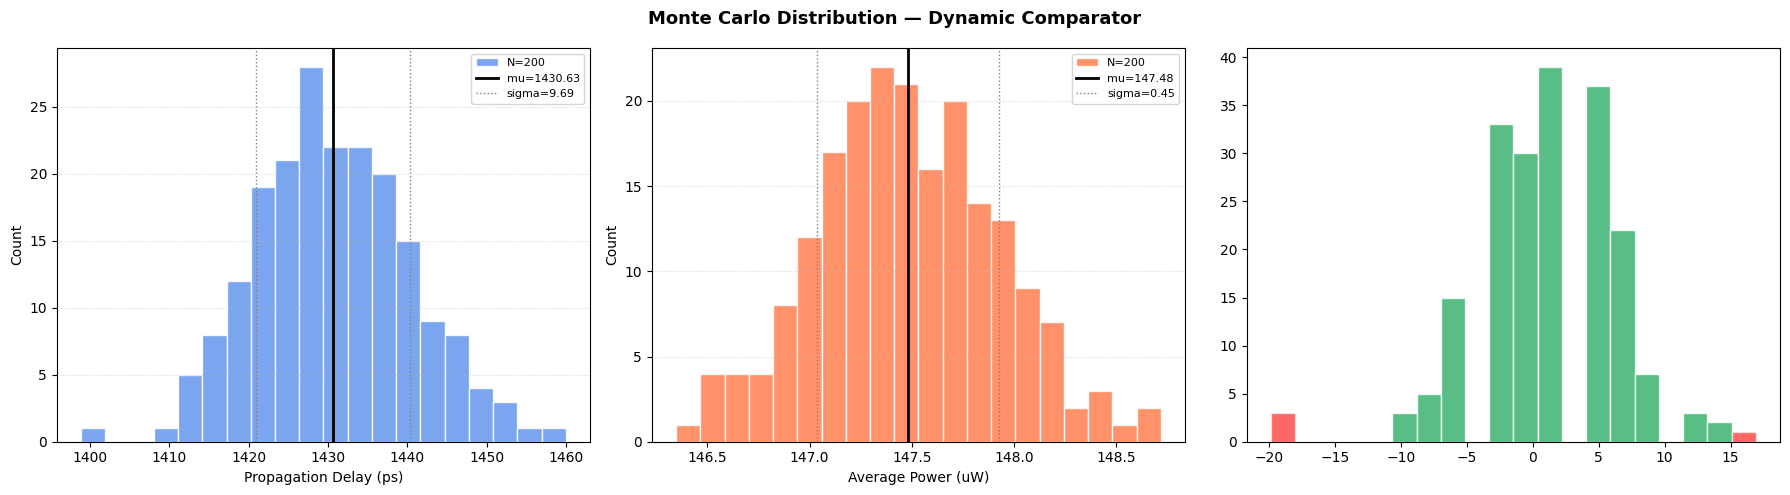

Saved: /foss/designs/Chipathon-2026-OnChipSAR/designs/sar_adc/comparator/Testbench/mc_histograms.png


In [12]:
%%run_if RUN_MC

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Monte Carlo Distribution — Dynamic Comparator', fontsize=13, fontweight='bold')

specs = [
    ('tpd (ps)',  'Propagation Delay (ps)', SPEC_MAX_DELAY*1e12,  'cornflowerblue'),
    ('Pavg (uW)', 'Average Power (uW)',      SPEC_MAX_POWER*1e6,   'coral'),
    ('Vos (mV)',  'Dynamic Offset (mV)',     SPEC_MAX_OFFSET*1e3,  'mediumseagreen'),
]

for ax, (col, xlabel, spec_lim, color) in zip(axes, specs):
    vals = df_mc[col].dropna().values
    n, bins, patches = ax.hist(vals, bins=20, color=color, edgecolor='white',
                                alpha=0.85, label=f'N={len(vals)}')
    for patch, left in zip(patches, bins[:-1]):
        if abs(left) > spec_lim:
            patch.set_facecolor('red'); patch.set_alpha(0.6)

    #ax.axvline(spec_lim, color='red', linestyle='--', linewidth=1.5,
               #label=f'Spec={spec_lim:.1f}')
    if col == 'Vos (mV)':
        continue
        #ax.axvline(-spec_lim, color='red', linestyle='--', linewidth=1.5)

    mu, sigma = vals.mean(), vals.std()
    ax.axvline(mu, color='black', linewidth=2, label=f'mu={mu:.2f}')
    ax.axvline(mu + sigma, color='gray', linewidth=1, linestyle=':', label=f'sigma={sigma:.2f}')
    ax.axvline(mu - sigma, color='gray', linewidth=1, linestyle=':')

    ax.set_xlabel(xlabel); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
out_path = os.path.join(os.getcwd(), 'mc_histograms.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

,Parameter,"Typical\n(TT, 3.3V, 27°C)",PVT Min / Max\n(45 corners),"Monte Carlo\n(µ ± σ, N=200)",Spec,Yield
0,Propagation Delay,1430.28 ps,778.72 / 3276.51 ps,1430.63 ± 9.71 ps,< 3000.00 ps,100.0 %
1,Average Power,147.42 uW,90.89 / 218.15 uW,147.48 ± 0.45 uW,< 250.00 uW,100.0 %
2,Dynamic Offset,1.91 mV,-19.89 / 2.41 mV,1.02 ± 5.54 mV,± 15.00 mV,98.0 %
3,Combined Yield,—,—,—,All specs,98.0 %


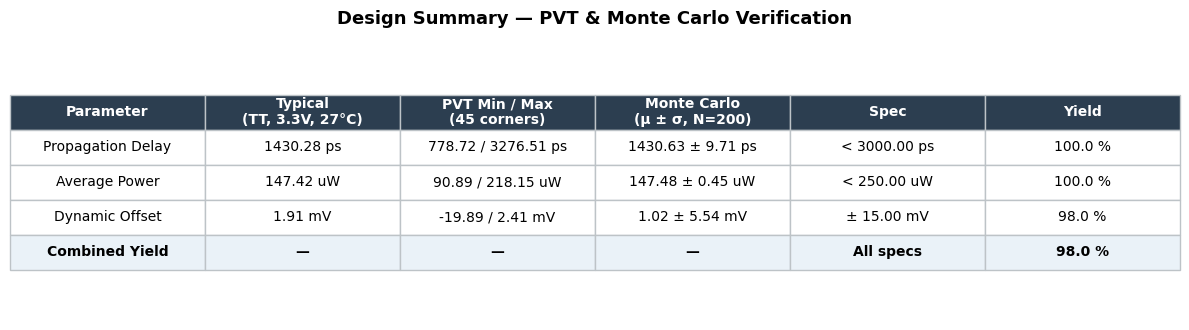

Saved: /foss/designs/Chipathon-2026-OnChipSAR/designs/sar_adc/comparator/Testbench/design_summary.png


In [9]:
%%run_if RUN_PVT_MC


# ── Design Summary Table (PVT + Monte Carlo) — Paper Ready ────────────────────
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

metrics = [
    ('tpd (ps)',  'Propagation Delay',  'ps', SPEC_MAX_DELAY  * 1e12, '<'),
    ('Pavg (uW)', 'Average Power',      'uW', SPEC_MAX_POWER  * 1e6,  '<'),
    ('Vos (mV)',  'Dynamic Offset',     'mV', SPEC_MAX_OFFSET * 1e3,  '<abs'),
]

# Typical corner from PVT (Process=typical, VDD=3.3V, Temp=27C)
typ_row = df_pvt[(df_pvt['Process'] == 'typical') &
                 (df_pvt['VDD (V)'] == 3.3) &
                 (df_pvt['Temp (C)'] == 27)]

summary_data = []
for col, label, unit, spec, cmp_type in metrics:
    # PVT worst-case range (across all 45 corners)
    pvt_min = df_pvt[col].min()
    pvt_max = df_pvt[col].max()
    typ_val = typ_row[col].values[0] if not typ_row.empty else np.nan

    # Monte Carlo stats
    mc_vals = df_mc[col].dropna()
    mc_mean = mc_vals.mean()
    mc_std  = mc_vals.std()

    if cmp_type == '<abs':
        yld = (mc_vals.abs() <= spec).mean() * 100
        spec_str = f"± {spec:.2f} {unit}"
    else:
        yld = (mc_vals <= spec).mean() * 100
        spec_str = f"< {spec:.2f} {unit}"

    summary_data.append([
        label,
        f"{typ_val:.2f} {unit}",
        f"{pvt_min:.2f} / {pvt_max:.2f} {unit}",
        f"{mc_mean:.2f} ± {mc_std:.2f} {unit}",
        spec_str,
        f"{yld:.1f} %",
    ])

# Combined yield (all specs simultaneously)
combined_mask = (
    (df_mc['tpd (ps)']       <= SPEC_MAX_DELAY  * 1e12) &
    (df_mc['Pavg (uW)']      <= SPEC_MAX_POWER  * 1e6 ) &
    (df_mc['Vos (mV)'].abs() <= SPEC_MAX_OFFSET * 1e3 )
)
summary_data.append(['Combined Yield', '—', '—', '—', 'All specs', f"{combined_mask.mean()*100:.1f} %"])

columns = ['Parameter', 'Typical\n(TT, 3.3V, 27°C)', 'PVT Min / Max\n(45 corners)',
           'Monte Carlo\n(µ ± σ, N=%d)' % len(df_mc), 'Spec', 'Yield']

df_summary = pd.DataFrame(summary_data, columns=columns)
display(df_summary)

# ── Render as figure/table image ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 1.2 + 0.55 * len(df_summary)))
ax.axis('off')

table = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)

# Header styling
for j, col in enumerate(df_summary.columns):
    cell = table[0, j]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(color='white', fontweight='bold')

# Highlight combined yield row
last_row = len(df_summary)
for j in range(len(df_summary.columns)):
    table[last_row, j].set_facecolor('#eaf2f8')
    table[last_row, j].set_text_props(fontweight='bold')

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#bdc3c7')

ax.set_title('Design Summary — PVT & Monte Carlo Verification',
              fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
out_path = os.path.join(os.getcwd(), 'design_summary.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")